In [ ]:
import pandas as pd
import glob
import os
import io

path = '/content/drive/MyDrive/Colab Notebooks/Sheryar/Training'

csv_files = glob.glob(os.path.join(path, "*.csv"))

data_dict = {}
target_cols = ['B1', 'B2', 'B3', 'B4']

for f in csv_files:
    df_name = os.path.splitext(os.path.basename(f))[0]
    print(f"Processing: {df_name}")

    try:
        with open(f, 'r') as file:
            lines = file.readlines()
        header_line = lines[7].lstrip(';').strip()
        data_lines = [line.strip() for line in lines[9:]]

        csv_content = "\n".join([header_line] + data_lines)

        df = pd.read_csv(io.StringIO(csv_content), sep=',', skipinitialspace=True)

        available_cols = [col for col in target_cols if col in df.columns]
        data_dict[df_name] = df[available_cols]

        print(f"  Successfully loaded {df_name} with shape: {data_dict[df_name].shape}")
        if not data_dict[df_name].empty:
             display(data_dict[df_name].head(2))
    except Exception as e:
        print(f"  Error processing {f}: {e}")

print(f"\nCreated {len(data_dict)} separate DataFrames.")

Processing: urban
  Successfully loaded urban with shape: (495553, 4)


,B1,B2,B3,B4
0,298,332,261,263
1,305,343,271,272


Processing: water
  Successfully loaded water with shape: (386814, 4)


,B1,B2,B3,B4
0,235,251,186,185
1,236,250,187,177


Processing: road
  Successfully loaded road with shape: (69203, 4)


...

Processing: cpf-253
  Successfully loaded cpf-253 with shape: (133030, 4)


,B1,B2,B3,B4
0,244,262,189,243
1,244,263,188,247


Processing: sl-284
  Successfully loaded sl-284 with shape: (232509, 4)


,B1,B2,B3,B4
0,247,261,188,257
1,251,266,191,263



Created 5 separate DataFrames.


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

all_dfs = []
MAX_PIXELS_PER_CLASS = 133000

print("Processing individual dataframes for pixel limit and class labeling...")
for class_name, df in data_dict.items():
    if len(df) > MAX_PIXELS_PER_CLASS:
        df_sampled = df.sample(n=MAX_PIXELS_PER_CLASS, random_state=42).copy()
        print(f"  Class '{class_name}' sampled from {len(df)} to {MAX_PIXELS_PER_CLASS} pixels.")
    else:
        df_sampled = df.copy()
        print(f"  Class '{class_name}' (size: {len(df)}) kept as is.")

    df_sampled['class'] = class_name
    all_dfs.append(df_sampled)

final_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nCombined final_df created with shape: {final_df.shape}")
print("First 5 rows of final_df with class labels (strings):")
display(final_df.head())

bands_df = final_df[['B1', 'B2', 'B3', 'B4']].copy()

B = bands_df['B1']
G = bands_df['B2']
R = bands_df['B3']
NIR = bands_df['B4']

bands_df['GNDVI'] = (NIR - G) / (NIR + G + 1e-6)

bands_df['EVI'] = 2.5 * ((NIR - R) / (NIR + 6 * R - 7.5 * B + 1 + 1e-6))

bands_df['SAVI'] = ((NIR - R) * (1 + 0.5)) / (NIR + R + 0.5 + 1e-6)

engineered_df = bands_df

print(f"\nDataFrame after feature engineering: {engineered_df.shape}")
print("First 5 rows of engineered_df before normalization:")
display(engineered_df.head())

feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']

scaler = StandardScaler()

engineered_df[feature_cols] = scaler.fit_transform(engineered_df[feature_cols])

print(f"\nDataFrame after normalization: {engineered_df.shape}")
print("First 5 rows of engineered_df after normalization:")
display(engineered_df.head())

engineered_df['class'] = final_df['class']

label_encoder = LabelEncoder()
engineered_df['class'] = label_encoder.fit_transform(engineered_df['class'])

print(f"\nFinal DataFrame with engineered and normalized features and INTEGER class labels: {engineered_df.shape}")
print("First 5 rows of the final engineered DataFrame:")
display(engineered_df.head())
print(f"\nMapping of original class names to integer labels: {list(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Processing individual dataframes for pixel limit and class labeling...
  Class 'urban' sampled from 495553 to 133000 pixels.
  Class 'water' sampled from 386814 to 133000 pixels.
  Class 'road' (size: 69203) kept as is.
  Class 'cpf-253' sampled from 133030 to 133000 pixels.
  Class 'sl-284' sampled from 232509 to 133000 pixels.

Combined final_df created with shape: (601203, 5)
First 5 rows of final_df with class labels (strings):


,B1,B2,B3,B4,class
0,295,328,256,250,urban
1,309,356,290,294,urban
2,272,297,231,229,urban
3,267,293,232,230,urban
4,286,323,260,261,urban



DataFrame after feature engineering: (601203, 7)
First 5 rows of engineered_df before normalization:


,B1,B2,B3,B4,GNDVI,EVI,SAVI
0,295,328,256,250,-0.134948,0.035253,-0.017769
1,309,356,290,294,-0.095385,-0.035398,0.010265
2,272,297,231,229,-0.129278,0.011792,-0.006515
3,267,293,232,230,-0.120459,0.013175,-0.006486
4,286,323,260,261,-0.106164,-0.007740,0.002876



DataFrame after normalization: (601203, 7)
First 5 rows of engineered_df after normalization:


,B1,B2,B3,B4,GNDVI,EVI,SAVI
0,1.789503,1.760431,1.705475,0.636244,-0.572182,0.816080,-0.777244
1,2.371835,2.634910,2.775345,1.836813,-0.029561,0.486165,-0.564209
2,0.832817,0.792257,0.918805,0.063245,-0.494409,0.706529,-0.691721
3,0.624841,0.667331,0.950272,0.090531,-0.373459,0.712986,-0.691507
4,1.415148,1.604274,1.831342,0.936386,-0.177408,0.615320,-0.620358



Final DataFrame with engineered and normalized features and INTEGER class labels: (601203, 8)
First 5 rows of the final engineered DataFrame:


,B1,B2,B3,B4,GNDVI,EVI,SAVI,class
0,1.789503,1.760431,1.705475,0.636244,-0.572182,0.816080,-0.777244,3
1,2.371835,2.634910,2.775345,1.836813,-0.029561,0.486165,-0.564209,3
2,0.832817,0.792257,0.918805,0.063245,-0.494409,0.706529,-0.691721,3
3,0.624841,0.667331,0.950272,0.090531,-0.373459,0.712986,-0.691507,3
4,1.415148,1.604274,1.831342,0.936386,-0.177408,0.615320,-0.620358,3



Mapping of original class names to integer labels: [('cpf-253', np.int64(0)), ('road', np.int64(1)), ('sl-284', np.int64(2)), ('urban', np.int64(3)), ('water', np.int64(4))]



--- Model Hyperparameters ---
Random State: 42
Test Size: 0.2
Number of Convolutional Layers: 2
Kernel Size: 3
Learning Rate: 0.001
Batch Size: 64
Epochs: 5
Optimizer: Adam
Dropout Rate: 0.3
-------------------------------

Training data (reshaped) shape: (480962, 7, 1)
Test data (reshaped) shape: (120241, 7, 1)
Training labels (one-hot) shape: (480962, 5)
Test labels (one-hot) shape: (120241, 5)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        38,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...


--- Per-class Performance (Test Set) ---


,Precision,Recall,F1-Score
Class,,,
cpf-253,0.827606,0.880902,0.853423
road,0.866784,0.856513,0.861618
sl-284,0.867876,0.842068,0.854777
urban,0.946927,0.943083,0.945001
water,0.986513,0.962406,0.974310



--- Feature Importance (Permutation Importance) ---


,Importance
B3,0.442844
B2,0.345365
B1,0.331917
GNDVI,0.219484
B4,0.203458
EVI,0.046723
SAVI,0.008500


/tmp/ipykernel_11668/2683540678.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df.index, y=importance_df['Importance'], palette='viridis')


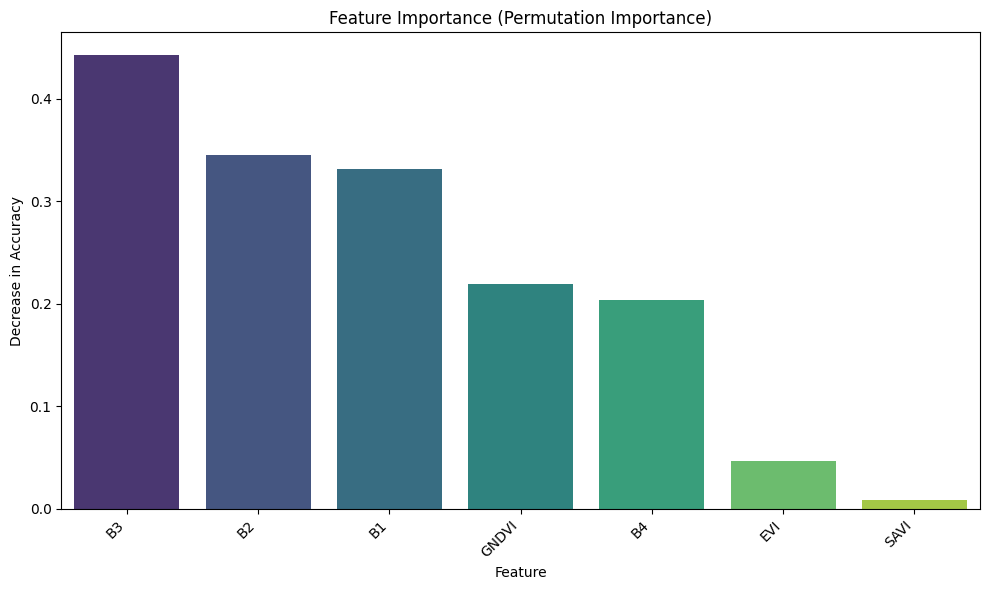

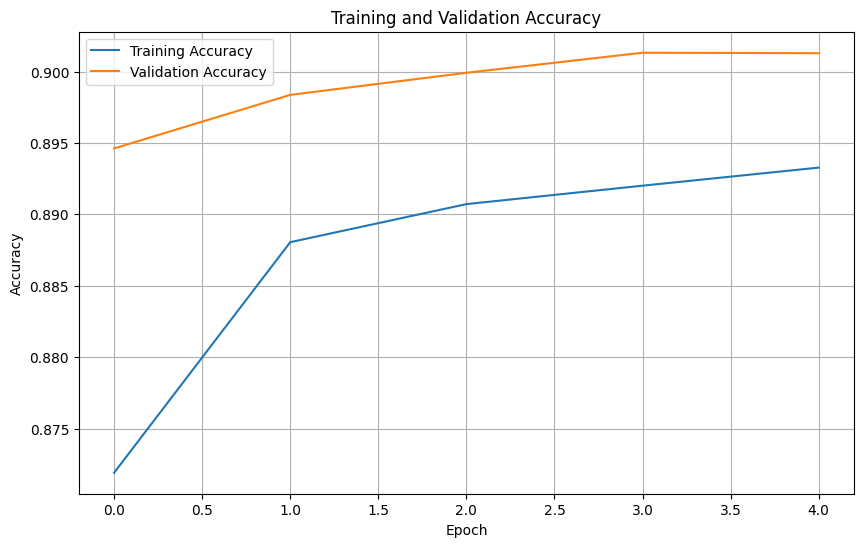

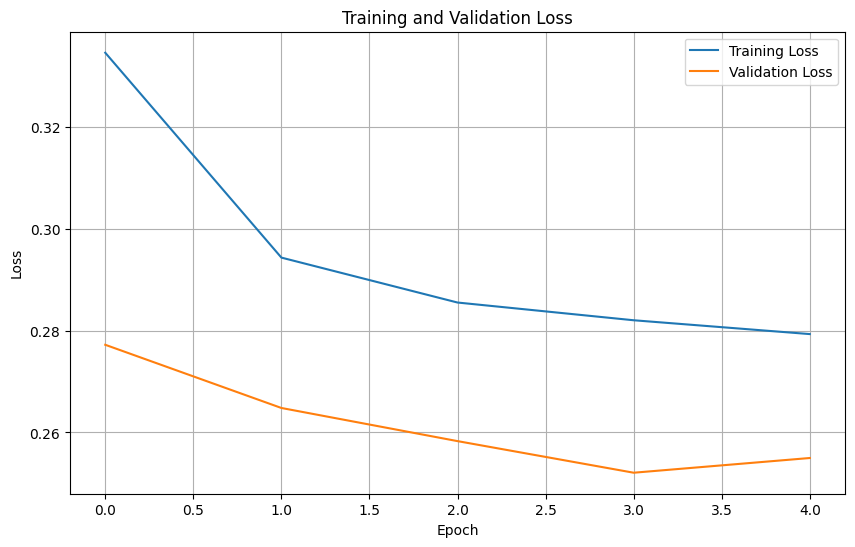

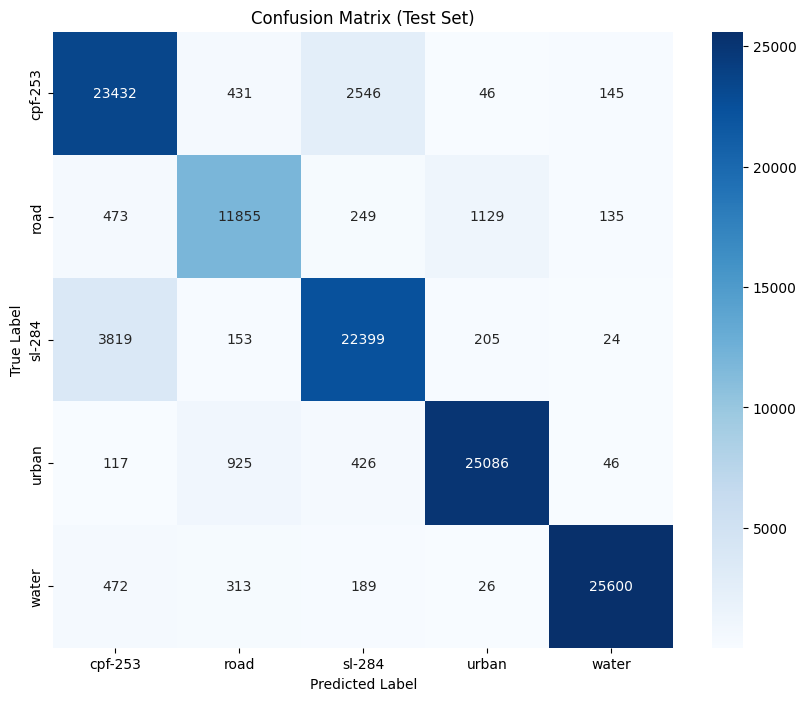

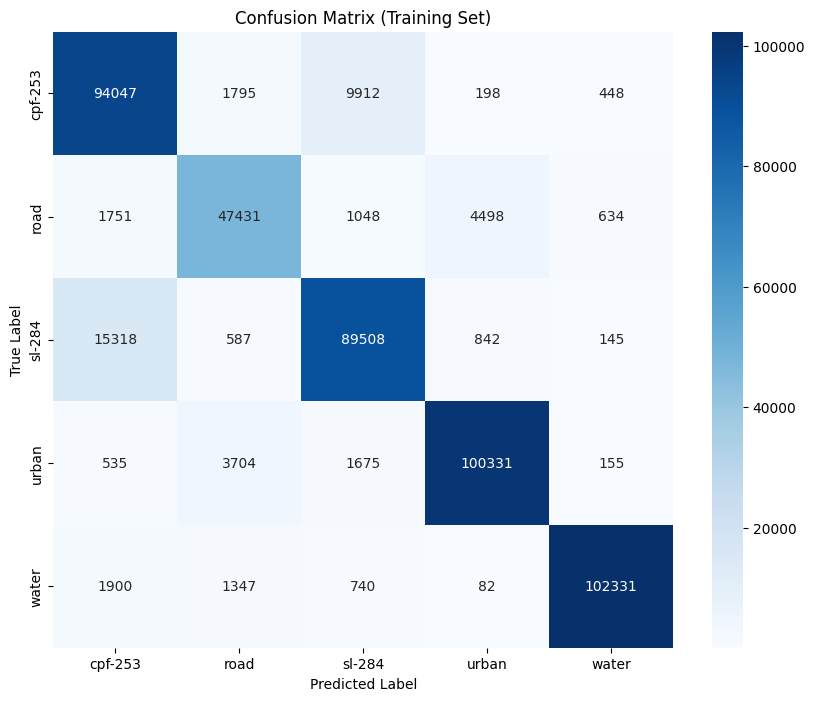


--- CNN Architecture Diagram ---


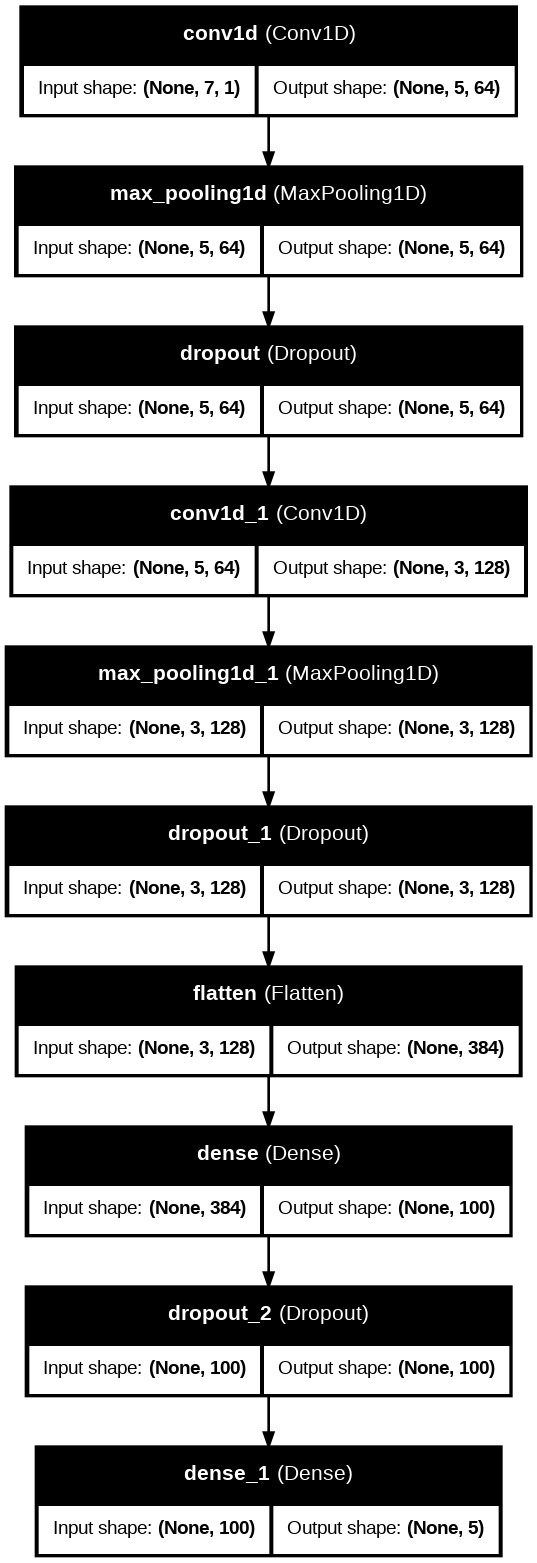


--- Epoch-wise Results ---


,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
0,0.871905,0.334571,0.894620,0.277220
1,0.888054,0.294339,0.898371,0.264810
2,0.890719,0.285516,0.899918,0.258302
3,0.892010,0.282036,0.901323,0.252096
4,0.893276,0.279320,0.901290,0.254986


---------------------------


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, cohen_kappa_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model

RANDOM_STATE = 42
TEST_SIZE = 0.20

NUM_CONV_LAYERS = 2
FILTERS_CONV1 = 64
FILTERS_CONV2 = 128
KERNEL_SIZE = 3
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 5
OPTIMIZER_TYPE = 'Adam'
DROPOUT_RATE = 0.3

print("\n--- Model Hyperparameters ---")
hyperparams = {
    "Random State": RANDOM_STATE,
    "Test Size": TEST_SIZE,
    "Number of Convolutional Layers": NUM_CONV_LAYERS,
    "Kernel Size": KERNEL_SIZE,
    "Learning Rate": LEARNING_RATE,
    "Batch Size": BATCH_SIZE,
    "Epochs": EPOCHS,
    "Optimizer": OPTIMIZER_TYPE,
    "Dropout Rate": DROPOUT_RATE
}
for param, value in hyperparams.items():
    print(f"{param}: {value}")
print("-------------------------------\n")

feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']
X = engineered_df[feature_cols]
y = engineered_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train_reshaped = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

num_classes = len(np.unique(y))
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

print(f"Training data (reshaped) shape: {X_train_reshaped.shape}")
print(f"Test data (reshaped) shape: {X_test_reshaped.shape}")
print(f"Training labels (one-hot) shape: {y_train_one_hot.shape}")
print(f"Test labels (one-hot) shape: {y_test_one_hot.shape}\n")

cnn_model = Sequential([
    Conv1D(filters=FILTERS_CONV1, kernel_size=KERNEL_SIZE, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
    MaxPooling1D(pool_size=1),
    Dropout(DROPOUT_RATE),
    Conv1D(filters=FILTERS_CONV2, kernel_size=KERNEL_SIZE, activation='relu'),
    MaxPooling1D(pool_size=1),
    Dropout(DROPOUT_RATE),
    Flatten(),
    Dense(100, activation='relu'),
    Dropout(DROPOUT_RATE),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=LEARNING_RATE)
cnn_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

print("\nCNN Model Summary:")
cnn_model.summary()

print("\nTraining CNN Model...")
history = cnn_model.fit(
    X_train_reshaped, y_train_one_hot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_reshaped, y_test_one_hot),
    verbose=1
)
print("Model training complete.\n")

if 'label_encoder' in globals():
    target_names = label_encoder.classes_
else:
    target_names = [str(i) for i in sorted(y.unique())]
    print("Warning: label_encoder not found. Using numeric class names for evaluation.")


y_train_pred_proba = cnn_model.predict(X_train_reshaped)
y_train_pred = np.argmax(y_train_pred_proba, axis=1)

y_test_pred_proba = cnn_model.predict(X_test_reshaped)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)

print("\n--- Overall Accuracy (OA) and Kappa Score ---")
oa_train = accuracy_score(y_train, y_train_pred)
oa_test = accuracy_score(y_test, y_test_pred)

kappa_train = cohen_kappa_score(y_train, y_train_pred)
kappa_test = cohen_kappa_score(y_test, y_test_pred)

accuracy_data = {
    "Metric": ["Overall Accuracy", "Kappa Score"],
    "Training Set": [oa_train, kappa_train],
    "Test Set": [oa_test, kappa_test]
}
accuracy_df = pd.DataFrame(accuracy_data).set_index("Metric")
display(accuracy_df)

print("\n=== Training Set Performance ===")
print("Classification Report:")
print(classification_report(y_train, y_train_pred, target_names=target_names))

print("\n=== Test Set Performance ===")
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

precision_train, recall_train, f1_train, _ = precision_recall_fscore_support(y_train, y_train_pred, labels=range(len(target_names)), average=None)
per_class_train_df = pd.DataFrame({
    'Class': target_names,
    'Precision': precision_train,
    'Recall': recall_train,
    'F1-Score': f1_train
}).set_index('Class')
print("\n--- Per-class Performance (Training Set) ---")
display(per_class_train_df)

precision_test, recall_test, f1_test, _ = precision_recall_fscore_support(y_test, y_test_pred, labels=range(len(target_names)), average=None)
per_class_test_df = pd.DataFrame({
    'Class': target_names,
    'Precision': precision_test,
    'Recall': recall_test,
    'F1-Score': f1_test
}).set_index('Class')
print("\n--- Per-class Performance (Test Set) ---")
display(per_class_test_df)

print("\n--- Feature Importance (Permutation Importance) ---")

baseline_accuracy = accuracy_score(y_test, y_test_pred)
feature_importance = {}

X_test_shuffled = X_test_reshaped.copy()

for i, feature_name in enumerate(feature_cols):
    X_temp = X_test_shuffled.copy()

    np.random.shuffle(X_temp[:, i, 0])

    y_shuffled_pred_proba = cnn_model.predict(X_temp, verbose=0)
    y_shuffled_pred = np.argmax(y_shuffled_pred_proba, axis=1)

    shuffled_accuracy = accuracy_score(y_test, y_shuffled_pred)

    importance = baseline_accuracy - shuffled_accuracy
    feature_importance[feature_name] = importance

importance_df = pd.DataFrame.from_dict(feature_importance, orient='index', columns=['Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df.index, y=importance_df['Importance'], palette='viridis')
plt.title('Feature Importance (Permutation Importance)')
plt.xlabel('Feature')
plt.ylabel('Decrease in Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Training Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- CNN Architecture Diagram ---")
plot_model(cnn_model, to_file='cnn_model_architecture.png', show_shapes=True, show_layer_names=True, rankdir='TB', dpi=96)
from IPython.display import Image
display(Image(filename='cnn_model_architecture.png'))

print("\n--- Epoch-wise Results ---")
epoch_results_df = pd.DataFrame(history.history)
epoch_results_df.index.name = 'Epoch'
display(epoch_results_df.head())

print("---------------------------")

Shape of the remaining (validation) dataset: (715906, 5)

Class distribution in the remaining (validation) dataset:
class
urban      362553
water      253814
sl-284      99509
cpf-253        30
Name: count, dtype: int64
22373/22373 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step

=== Performance on Remaining (Validation) Dataset ===
Overall Accuracy: 0.9361
Kappa Score: 0.8966
Classification Report:
              precision    recall  f1-score   support

     cpf-253       0.00      0.70      0.00        30
        road       0.00      0.00      0.00         0
      sl-284       0.91      0.82      0.86     99509
       urban       1.00      0.94      0.97    362553
       water       1.00      0.97      0.98    253814

    accuracy                           0.94    715906
   macro avg       0.58      0.69      0.56    715906
weighted avg       0.99      0.94      0.96    715906


--- Per-class Performance (Validation Set) ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

,Precision,Recall,F1-Score
Class,,,
cpf-253,0.000959,0.700000,0.001916
road,0.000000,0.000000,0.000000
sl-284,0.914549,0.818599,0.863918
urban,0.996684,0.944325,0.969799
water,0.997825,0.970565,0.984006



--- Overall Accuracy and Kappa Score Comparison (Research Paper Table) ---


,Training Set,Test Set,Validation Set
Metric,,,
Overall Accuracy,0.901626,0.901290,0.936142
Kappa Score,0.875615,0.875184,0.896579


...

,Training Precision,Test Precision,Validation Precision
Class,,,
cpf-253,0.828236,0.827606,0.000959
road,0.864520,0.866784,0.000000
sl-284,0.869998,0.867876,0.914549
urban,0.946957,0.946927,0.996684
water,0.986675,0.986513,0.997825



--- Per-class Recall Comparison (Research Paper Table) ---


,Training Recall,Test Recall,Validation Recall
Class,,,
cpf-253,0.883900,0.880902,0.700000
road,0.856743,0.856513,0.000000
sl-284,0.841241,0.842068,0.818599
urban,0.942961,0.943083,0.944325
water,0.961758,0.962406,0.970565



--- Per-class F1-Score Comparison (Research Paper Table) ---


,Training F1-Score,Test F1-Score,Validation F1-Score
Class,,,
cpf-253,0.855163,0.853423,0.001916
road,0.860614,0.861618,0.000000
sl-284,0.855378,0.854777,0.863918
urban,0.944954,0.945001,0.969799
water,0.974057,0.974310,0.984006


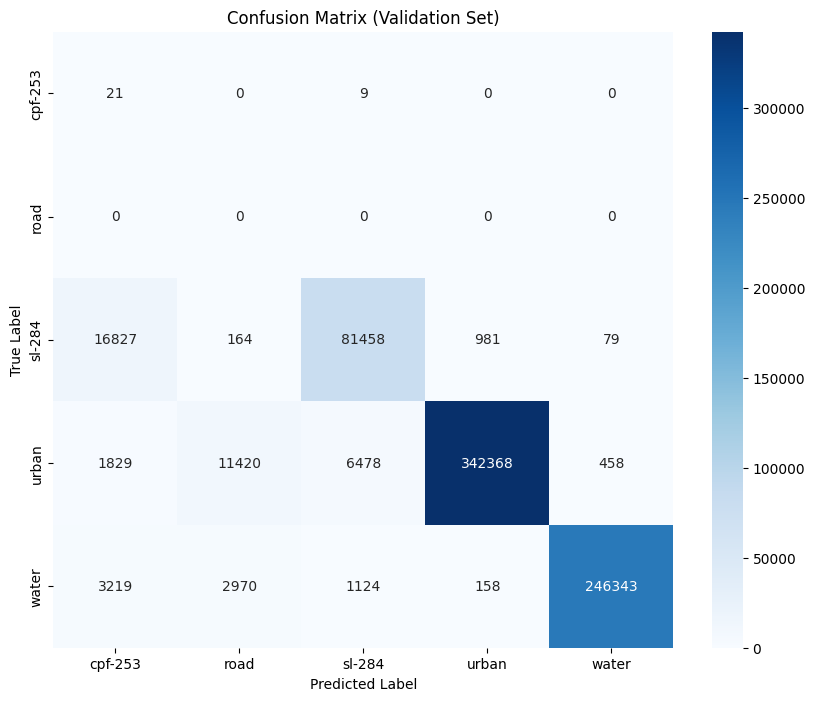


First 5 predictions on the remaining (validation) dataset:


,Actual,Predicted
0,water,water
1,water,water
2,water,water
3,water,water
4,water,water


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, cohen_kappa_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical

truncated_names = ['water', 'urban', 'sl-284', 'cpf-253']

remaining_data_list = []

for name in truncated_names:
    if name in data_dict:
        original_df = data_dict[name]

        if len(original_df) > MAX_PIXELS_PER_CLASS:
            remaining_df = original_df.iloc[MAX_PIXELS_PER_CLASS:].copy()
            if not remaining_df.empty:

                remaining_df['class'] = label_encoder.transform([name])[0]
                remaining_data_list.append(remaining_df)

if not remaining_data_list:
    print("No remaining data found to evaluate.")
else:

    remaining_df_full = pd.concat(remaining_data_list, ignore_index=True)

    print(f"Shape of the remaining (validation) dataset: {remaining_df_full.shape}")
    print("\nClass distribution in the remaining (validation) dataset:")

    print(remaining_df_full['class'].map(lambda x: target_names[x]).value_counts())

    B_rem = remaining_df_full['B1']
    G_rem = remaining_df_full['B2']
    R_rem = remaining_df_full['B3']
    NIR_rem = remaining_df_full['B4']

    remaining_df_full['GNDVI'] = (NIR_rem - G_rem) / (NIR_rem + G_rem + 1e-6)
    remaining_df_full['EVI'] = 2.5 * ((NIR_rem - R_rem) / (NIR_rem + 6 * R_rem - 7.5 * B_rem + 1 + 1e-6))
    remaining_df_full['SAVI'] = ((NIR_rem - R_rem) * (1 + 0.5)) / (NIR_rem + R_rem + 0.5 + 1e-6)

    feature_cols = ['B1', 'B2', 'B3', 'B4', 'GNDVI', 'EVI', 'SAVI']
    X_remaining = remaining_df_full[feature_cols]
    y_remaining = remaining_df_full['class']

    X_remaining_scaled = scaler.transform(X_remaining)

    X_remaining_reshaped = X_remaining_scaled.reshape(X_remaining_scaled.shape[0], X_remaining_scaled.shape[1], 1)

    y_remaining_pred_proba = cnn_model.predict(X_remaining_reshaped)
    y_remaining_pred = np.argmax(y_remaining_pred_proba, axis=1)

    print("\n=== Performance on Remaining (Validation) Dataset ===")

    oa_validation = accuracy_score(y_remaining, y_remaining_pred)
    kappa_validation = cohen_kappa_score(y_remaining, y_remaining_pred)

    print(f"Overall Accuracy: {oa_validation:.4f}")
    print(f"Kappa Score: {kappa_validation:.4f}")

    print("Classification Report:")
    print(classification_report(y_remaining, y_remaining_pred, target_names=target_names))

    precision_val, recall_val, f1_val, _ = precision_recall_fscore_support(y_remaining, y_remaining_pred, labels=range(len(target_names)), average=None)
    per_class_val_df = pd.DataFrame({
        'Class': target_names,
        'Precision': precision_val,
        'Recall': recall_val,
        'F1-Score': f1_val
    }).set_index('Class')
    print("\n--- Per-class Performance (Validation Set) ---")
    display(per_class_val_df)

    print("\n--- Overall Accuracy and Kappa Score Comparison (Research Paper Table) ---")
    comparison_accuracy_df = pd.DataFrame({
        "Metric": ["Overall Accuracy", "Kappa Score"],
        "Training Set": [oa_train, kappa_train],
        "Test Set": [oa_test, kappa_test],
        "Validation Set": [oa_validation, kappa_validation]
    }).set_index("Metric")
    display(comparison_accuracy_df)

    print("\n--- Per-class Precision Comparison (Research Paper Table) ---")
    precision_comparison_df = pd.DataFrame({
        'Class': target_names,
        'Training Precision': precision_train,
        'Test Precision': precision_test,
        'Validation Precision': precision_val
    }).set_index('Class')
    display(precision_comparison_df)

    print("\n--- Per-class Recall Comparison (Research Paper Table) ---")
    recall_comparison_df = pd.DataFrame({
        'Class': target_names,
        'Training Recall': recall_train,
        'Test Recall': recall_test,
        'Validation Recall': recall_val
    }).set_index('Class')
    display(recall_comparison_df)

    print("\n--- Per-class F1-Score Comparison (Research Paper Table) ---")
    f1_comparison_df = pd.DataFrame({
        'Class': target_names,
        'Training F1-Score': f1_train,
        'Test F1-Score': f1_test,
        'Validation F1-Score': f1_val
    }).set_index('Class')
    display(f1_comparison_df)

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_remaining, y_remaining_pred), annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\nFirst 5 predictions on the remaining (validation) dataset:")
    display(pd.DataFrame({'Actual': y_remaining.map(lambda x: target_names[x]), 'Predicted': pd.Series(y_remaining_pred).map(lambda x: target_names[x])}).head())
